In [1]:
# Célula 1 — ambiente
using Pkg
Pkg.activate("/Users/danielbandrade/Documents/programing/BeforeIT-dba")

using JLD2, DataFrames, Dates, Plots

  Activating project at `~/Documents/programing/BeforeIT-dba`


In [2]:
# Célula 2 — carregar
file = "/Users/danielbandrade/Documents/programing/BeforeIT-dba/data/italy/calibration/calibration/2010Q1.jld2"

calibration_data = load(file, "calibration_data")

Dict{String, Any} with 35 entries:
  "social_benefits"                  => [298695.0; 304478.0; … ; 332914.0; 3363…
  "government_debt_quarterly"        => [1.87615e6; 1.90049e6; … ; 2.44131e6; 2…
  "capital_taxes"                    => [3517.0; 6986.0; … ; 1214.0; 5360.0;;]
  "interest_government_debt"         => [68926.0; 76657.0; … ; 68093.0; 66388.0…
  "dwellings_eu7"                    => [290.2 282.8 … 259.0 269.9; 345.9 329.8…
  "pension_benefits"                 => [214091.0; 218439.0; … ; 227115.0; 2272…
  "nace64_capital_consumption_eu20"  => [36782.0 37676.6 … 40079.2 40510.5; 202…
  "fixed_assets_eu7"                 => [1.18039e5 1.19816e5 … 1.23073e5 1.2428…
  "firm_interest"                    => [99223.0; 119101.0; … ; 63711.0; 53230.…
  "dwellings"                        => [2.57172e6; 2.68011e6; … ; 2.78538e6; 2…
  "nominal_nace64_output_eu20"       => [2.48356e5 2.68481e5 … 2.75012e5 273985…
  "social_contributions"             => [213679.0; 216362.0; … ; 219130.0; 2

In [3]:
# Célula 3 — inventário das 35 variáveis
names = sort(collect(keys(calibration_data)))

DataFrame(
    variable = names,
    dimensions = [size(calibration_data[name]) for name in names],
    minimum = [minimum(calibration_data[name]) for name in names],
    maximum = [maximum(calibration_data[name]) for name in names],
)

Row,variable,dimensions,minimum,maximum
,String,Tuple…,Float64,Float64
1,bank_equity_quarterly,"(40, 1)",99014.0,282271.0
2,capital_consumption,"(7, 1)",23863.3,65642.3
3,capital_taxes,"(7, 1)",1214.0,6986.0
4,corporate_tax,"(7, 1)",32422.0,39566.0
5,dwellings,"(7, 1)",2.57172e6,2.80941e6
6,dwellings_eu7,"(62, 7)",0.0,1.79203e6
7,employees,"(62, 7)",15500.0,1.463e6
8,firm_cash_quarterly,"(40, 1)",227304.0,388388.0
9,firm_debt_quarterly,"(40, 1)",1.07622e6,1.25399e6


In [15]:
# Célula 4 — examinar uma variável
name = "fixed_assets"
values = calibration_data[name]

display(values)
values[1:min(10, size(values, 1)), :]

7×1 Matrix{Float64}:
 5.5772897e6
 5.7922161e6
 5.8679164e6
 5.8483e6
 5.8305552e6
 5.8413967e6
 5.8496236e6

7×1 Matrix{Float64}:
 5.5772897e6
 5.7922161e6
 5.8679164e6
 5.8483e6
 5.8305552e6
 5.8413967e6
 5.8496236e6

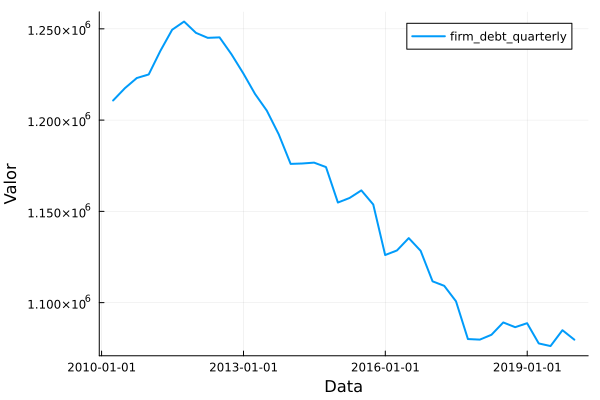

In [5]:
# Célula 5 — visualizar uma série trimestral
num2date(n) =
    DateTime(-1, 12, 31) + Millisecond(round(Int, n * 86_400_000))

quarter_dates = num2date.(vec(calibration_data["quarters_num"]))
name = "firm_debt_quarterly"

plot(
    quarter_dates,
    vec(calibration_data[name]);
    label = name,
    xlabel = "Data",
    ylabel = "Valor",
    linewidth = 2,
)

Row,date,value
,DateTime,Float64
1,2010-12-31T00:00:00,4.67106e5
2,2011-12-31T00:00:00,4.73625e5
3,2012-12-31T00:00:00,4.67743e5
4,2013-12-31T00:00:00,4.63726e5
5,2014-12-31T00:00:00,4.66183e5
6,2015-12-31T00:00:00,4.76964e5
7,2016-12-31T00:00:00,4.90653e5


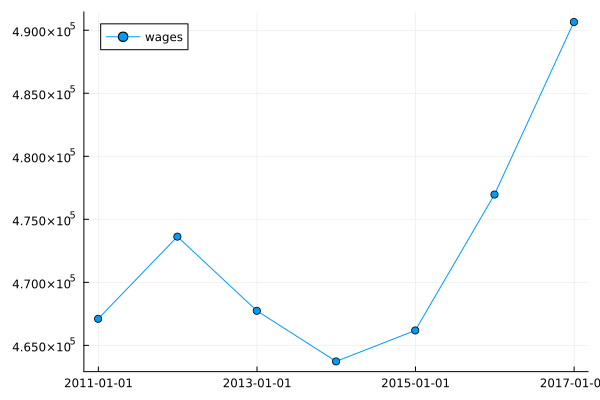

In [6]:
# Célula 6 — visualizar uma série anual
year_dates = num2date.(vec(calibration_data["years_num"]))
name = "wages"

annual = DataFrame(
    date = year_dates,
    value = vec(calibration_data[name]),
)

display(annual)
plot(annual.date, annual.value; label=name, marker=:circle)

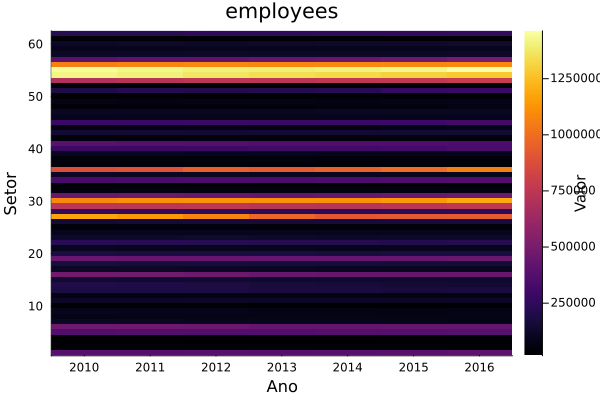

In [7]:
# Célula 7 — mapa de calor de uma variável setorial (62 setores × 7 anos)
name = "employees"
values = calibration_data[name]

heatmap(
    year.(year_dates),
    1:size(values, 1),
    values;
    xlabel = "Ano",
    ylabel = "Setor",
    title = name,
    colorbar_title = "Valor",
)

In [8]:
firms = calibration_data["firms"]
employees = calibration_data["employees"]

dates = Date.(
    DateTime(-1, 12, 31) .+
    Millisecond.(round.(Int, vec(calibration_data["years_num"]) .* 86_400_000))
)
years = year.(dates)

@assert size(firms) == (62, 7)

In [9]:
# Firmas por setor e ano
firms_by_sector = DataFrame(firms, Symbol.(string.(years)))
insertcols!(firms_by_sector, 1, :sector => 1:size(firms, 1))

firms_by_sector

Row,sector,2010,2011,2012,2013,2014,2015,2016
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,37540.0,37280.0,38270.0,37480.0,38330.0,39020.0,40940.0
2,2,2700.0,3400.0,3300.0,3270.0,3300.0,3360.0,3360.0
3,3,2000.0,1960.0,1860.0,1840.0,1870.0,1970.0,2000.0
4,4,2522.0,2493.0,2451.0,2336.0,2257.0,2186.0,2140.0
5,5,57139.0,58077.0,57995.0,57646.0,56418.0,56321.0,56757.0
6,6,64165.0,64464.0,63359.0,61062.0,59237.0,57966.0,57333.0
7,7,33541.0,33779.0,31720.0,31216.0,30001.0,28163.0,27194.0
8,8,4130.0,4155.0,4054.0,3906.0,3801.0,3723.0,3763.0
9,9,16922.0,16577.0,16289.0,16131.0,15469.0,15109.0,15286.0


In [10]:
# Total nacional por ano
totals = vec(sum(firms; dims=1))

DataFrame(
    year = years,
    firms = Int.(totals),
    variation_pct = [
        missing
        round.(100 .* diff(totals) ./ totals[1:end-1]; digits=2)
    ],
)

Row,year,firms,variation_pct
,Int64,Int64,Float64?
1,2010,4660448,missing
2,2011,4651694,-0.19
3,2012,4638819,-0.28
4,2013,4583249,-1.2
5,2014,4551438,-0.69
6,2015,4529461,-0.48
7,2016,4581555,1.15


In [11]:
# Maiores setores e empregados por firma
selected_year = 2016
column = only(findall(==(selected_year), years))
ranking = sortperm(firms[:, column]; rev=true)

sector_ranking = DataFrame(
    sector = ranking,
    firms = Int.(firms[ranking, column]),
    employees = Int.(employees[ranking, column]),
)

sector_ranking.employees_per_firm =
    round.(sector_ranking.employees ./ sector_ranking.firms; digits=2)

sector_ranking.share_pct =
    round.(100 .* sector_ranking.firms ./ sum(sector_ranking.firms); digits=2)

first(sector_ranking, 15)

Row,sector,firms,employees,employees_per_firm,share_pct
,Int64,Int64,Int64,Float64,Float64
1,30,606224,1186400,1.96,13.23
2,27,508696,926500,1.82,11.1
3,29,383304,751400,1.96,8.37
4,45,352076,302800,0.86,7.68
5,36,323563,1056800,3.27,7.06
6,56,278280,1093300,3.93,6.07
7,44,243883,75600,0.31,5.32
8,46,203181,88500,0.44,4.43
9,62,185604,258900,1.39,4.05


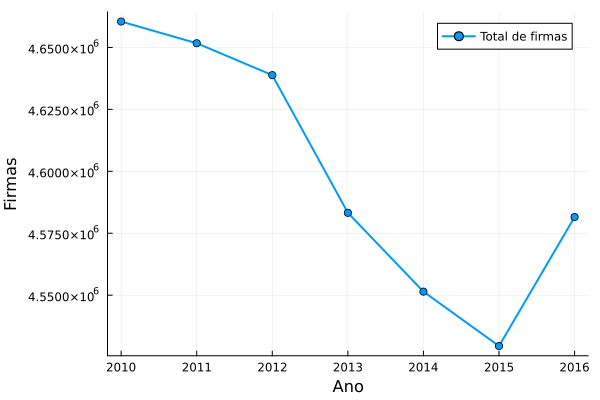

In [12]:
# Evolução do total de firmas
plot(
    years,
    totals;
    marker=:circle,
    linewidth=2,
    label="Total de firmas",
    xlabel="Ano",
    ylabel="Firmas",
)

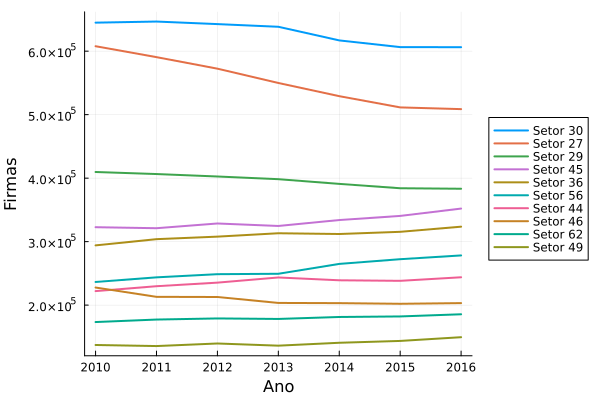

In [13]:
# Evolução dos 10 maiores setores
top10 = ranking[1:10]

plot(
    years,
    firms[top10, :]';
    label=permutedims("Setor " .* string.(top10)),
    xlabel="Ano",
    ylabel="Firmas",
    linewidth=2,
    legend=:outerright,
)